In [1]:
from utils.binaries import *
from utils.plotting import *
from datetime import date, datetime

from utils.auger.fd.XYScanner import Telescope

15:32:14 (  +20.1s) [INFO   ] -- import logging
15:32:14 (  +196ms) [INFO   ] -- import numpy as np
15:32:14 (   +15ms) [INFO   ] -- import uncertainties
15:32:15 (  +940ms) [INFO   ] -- import pandas as pd
15:32:15 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
15:32:15 (    +3ms) [INFO   ] -- import binaries.tools as tools
15:32:15 (    +3ms) [INFO   ] -- set MONI_PATH = PosixPath('/cr/work/filip/monit_and_sd')
15:32:15 (    +1ms) [INFO   ] -- set HIST_PATH = PosixPath('/cr/work/filip/monit_and_sd')
15:32:15 (    +0ms) [INFO   ] -- set PLOT_PATH = PosixPath('/cr/data01/filip/plots')
15:32:15 (    +1ms) [INFO   ] -- set DATA_PATH = PosixPath('/cr/data01/filip/Data')
15:32:15 (    +1ms) [INFO   ] -- set SCAN_PATH = PosixPath('/cr/data01/filip/xy-calibration')
15:32:15 (    +1ms) [INFO   ] -- set OFLN_PATH = PosixPath('/cr/data01/filip/offline/install')
15:32:15 (  +688ms) [INFO   ] -- import matplotlib.pyplot as plt
15:32:17 (   +1.3s) [INFO   ] -- import seaborn a

In [2]:
# CalA = tools.pickle_load("CO1.pkl")
# CalA = CalA.loc[CalA['PixelId'] == 210, ['Date', 'CalibConstant']]
# tools.pickle_save("CO1_pixel210.pkl", CalA)

CO1 = Telescope("CO1")[0]
CalA = tools.pickle_load("CO1_pixel210.pkl")
CalA.loc[CalA['CalibConstant'] > 10, 'CalibConstant'] = np.nan

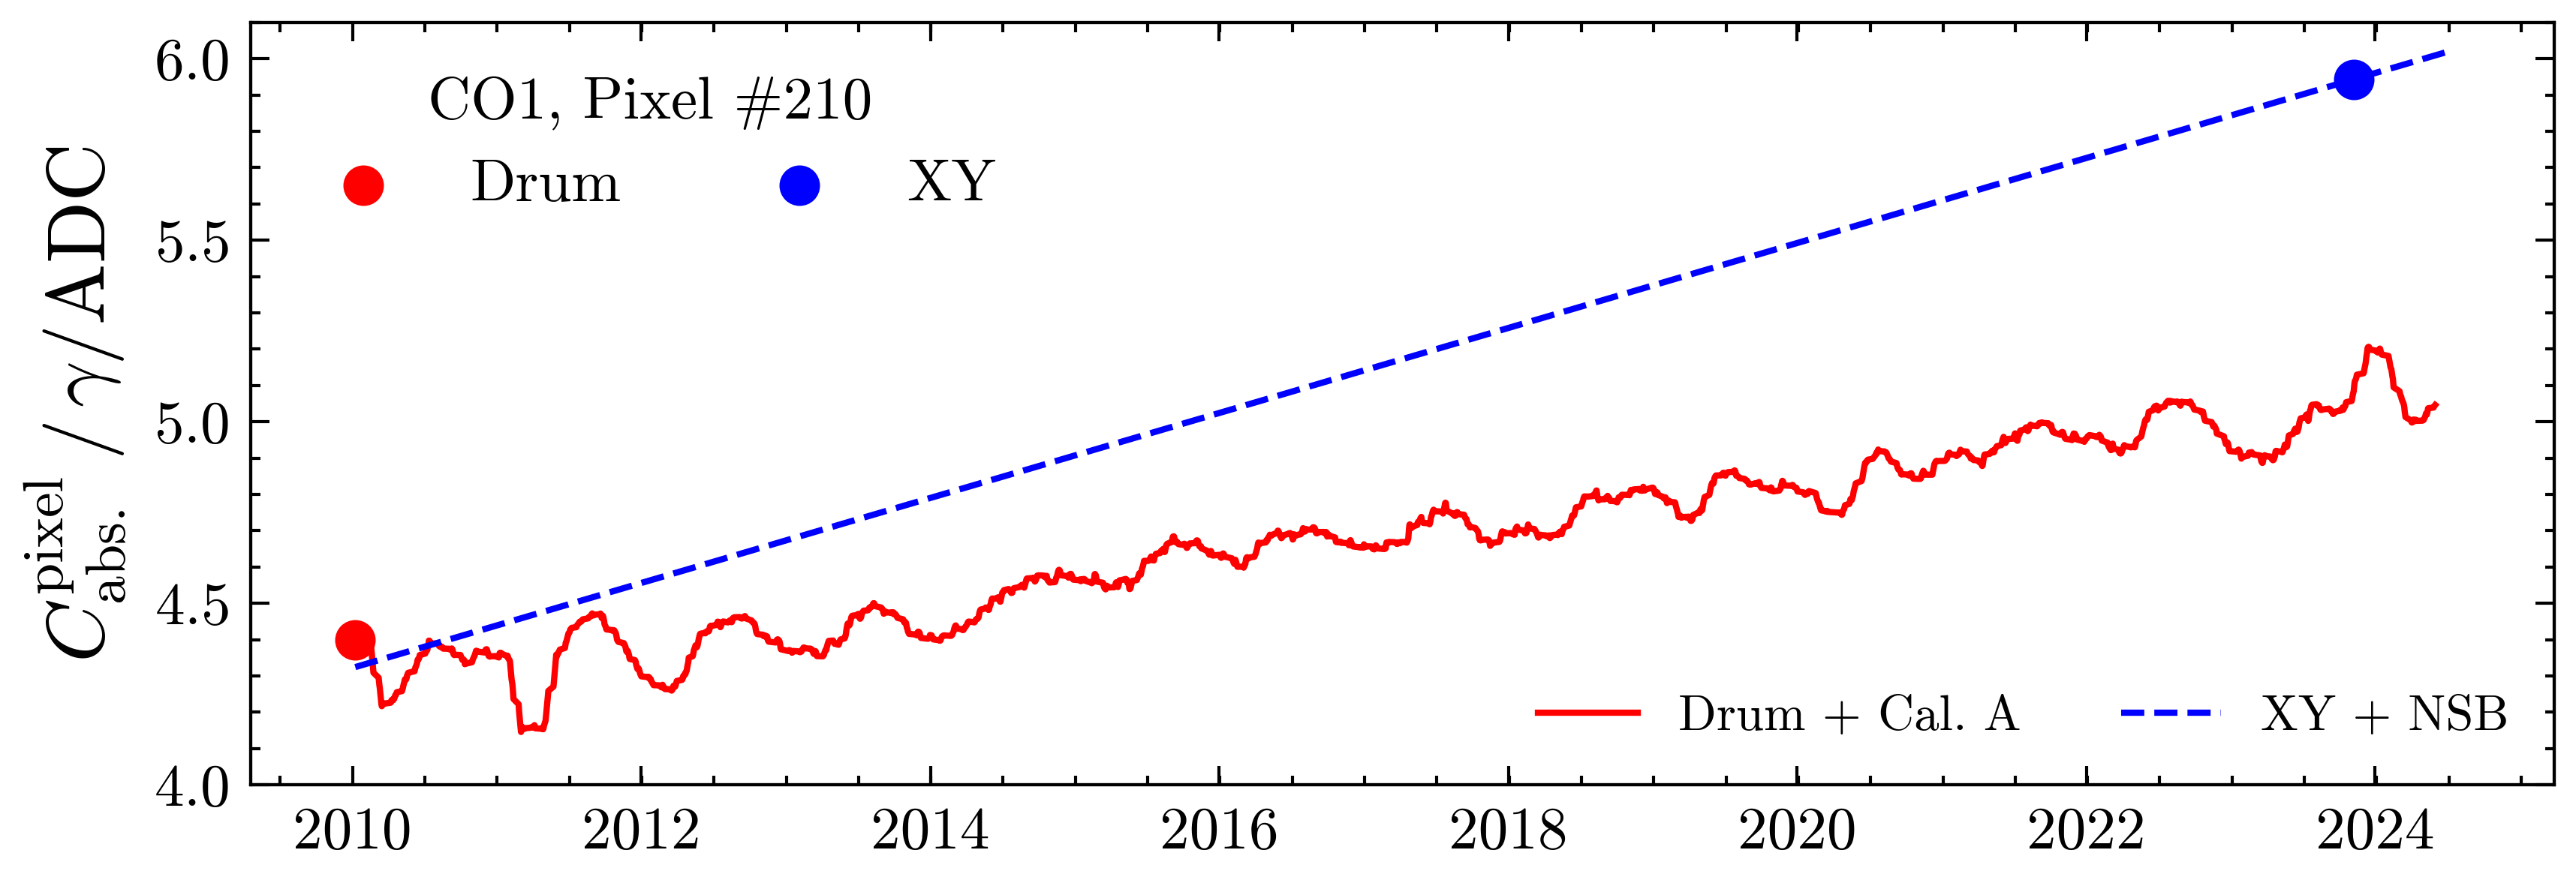

In [9]:
set_plt_style("slim")

XY_pixel = CO1.get_data("XY")[209]
XY_date = datetime.strptime(CO1.year_month_day, '%Y-%m-%d').date()
Drum_pixel = 4.4
Drum_date = CalA.iloc[0, 0]

def lin_int(x, y, start_date=Drum_date, stop_date=XY_date, stop_val=XY_pixel):
    x = np.array([(f - start_date).days for f in x])
    stop_date = (stop_date - start_date).days

    fraction_time = x / stop_date

    return y * (1-fraction_time) + stop_val * fraction_time

def nsb_drift(x, anchor_date=XY_date, anchor_val=XY_pixel, nsb_drift=0.019689854):

    x = np.array([(anchor_date-f).days / 365.25 for f in x])

    return anchor_val * (1-x*nsb_drift)

def nsb_drift_interpolation_cal_a(x, y, start_date=Drum_date, 
                                  stop_date=XY_date, stop_val=XY_pixel,
                                  nsb_drift=0.019689854):
    
    x1 = np.array([(stop_date-f).days / 365.25 for f in x])
    stop_val = stop_val * (1-x1*nsb_drift)

    x = np.array([(f - start_date).days for f in x])
    stop_date = (stop_date - start_date).days

    fraction_time = x / stop_date

    return y * (1-fraction_time) + stop_val * fraction_time

ax1 = plt.gca()

plt.scatter(Drum_date, Drum_pixel, s=30, c='r', zorder=1, label='Drum')
plt.scatter(XY_date, XY_pixel, s=30, c='b', label="XY")

ymin, ymax = 4, 6.1
xmin, xmax = plt.gca().get_xlim()
plt.gca().set_ylim(ymin, ymax)

plt.legend(ncol=2, title='CO1, Pixel #210')
plt.ylabel("$C^\mathrm{pixel}_\mathrm{abs.}\,/\,\gamma/\mathrm{ADC}$")

ax = plt.gca().twinx()
ax.set_ylim(ymin, ymax)
# ax.set_xlim(xmin, xmax)
ax.set_yticklabels([])
ax.set_zorder(ax1.get_zorder()-1)
ax1.patch.set_visible(False)

ax.plot(*tools.running_mean(CalA['Date'], CalA['CalibConstant'], 50), 
        marker='none', zorder=0, label='Drum + Cal. A', c='r')

# ax.plot(*tools.running_mean(CalA['Date'], lin_int(CalA['Date'], CalA['CalibConstant']), 50), 
#         marker='none', label='Cal. A + XY')

ax.plot(CalA['Date'], nsb_drift(CalA['Date']), marker='none', label='XY + NSB', c='b')

# ax.plot(*tools.running_mean(CalA['Date'], nsb_drift_interpolation_cal_a(CalA['Date'], CalA['CalibConstant']), 50), 
#         marker='none', label='Cal. A + XY + NSB')

ax.legend(ncol=2, loc='lower right', fontsize=8)
plot.save(plt.gcf(), "tracking")

In [2]:
calA = tools.pickle_load('/cr/tempdata01/filip/cal_a_2010_2024/CO1.pkl')

array([4.26426, 4.50035, 4.34047, 4.07148, 4.48547, 4.27743, 4.52052,
       4.15388, 4.74906, 3.89516, 4.72314, 4.49715, 4.31509, 4.43082,
       4.04372, 4.21167, 4.21991, 4.59845, 4.46007, 4.56658, 4.38871,
       4.00646, 4.21334, 4.56075, 4.42187, 4.27771, 4.51335, 4.85829,
       4.37492, 4.27636, 4.31668, 4.09734, 4.11735, 4.20596, 4.27324,
       4.34205, 3.88433, 4.18244, 3.82125, 4.20162, 4.21313, 4.04339,
       4.03938, 4.29098, 4.14879, 4.0459 , 4.13386, 4.23367, 4.34174,
       3.90979, 3.8297 , 4.04098, 4.25294, 4.56305, 4.2142 , 4.42508,
       4.09876, 4.44986, 4.25585, 4.21067, 4.4915 , 3.92417, 3.89827,
       4.39808, 4.01621, 3.9141 , 4.19559, 4.52971, 4.36922, 4.27988,
       4.32914, 4.05528, 4.61062, 4.42415, 4.05993, 4.54144, 4.32313,
       4.51553, 4.38944, 4.48813, 3.9355 , 4.16974, 4.15591, 4.23924,
       4.4902 , 4.51228, 4.24963, 4.5566 , 4.28258, 4.03743, 4.26415,
       4.73742, 4.24938, 5.03832, 4.21904, 4.26917, 4.22258, 4.03719,
       4.4487 , 4.27

In [31]:
CO1 = Telescope("CO1")[0]
calA_then = calA[calA['Date'] == date(2010, 2, 6)]['CalibConstant']
calA_now = calA[calA['Date'] == date(*[int(s) for s in CO1.year_month_day.split("-")])]['CalibConstant']
XY_now = CO1.get_data("XY")

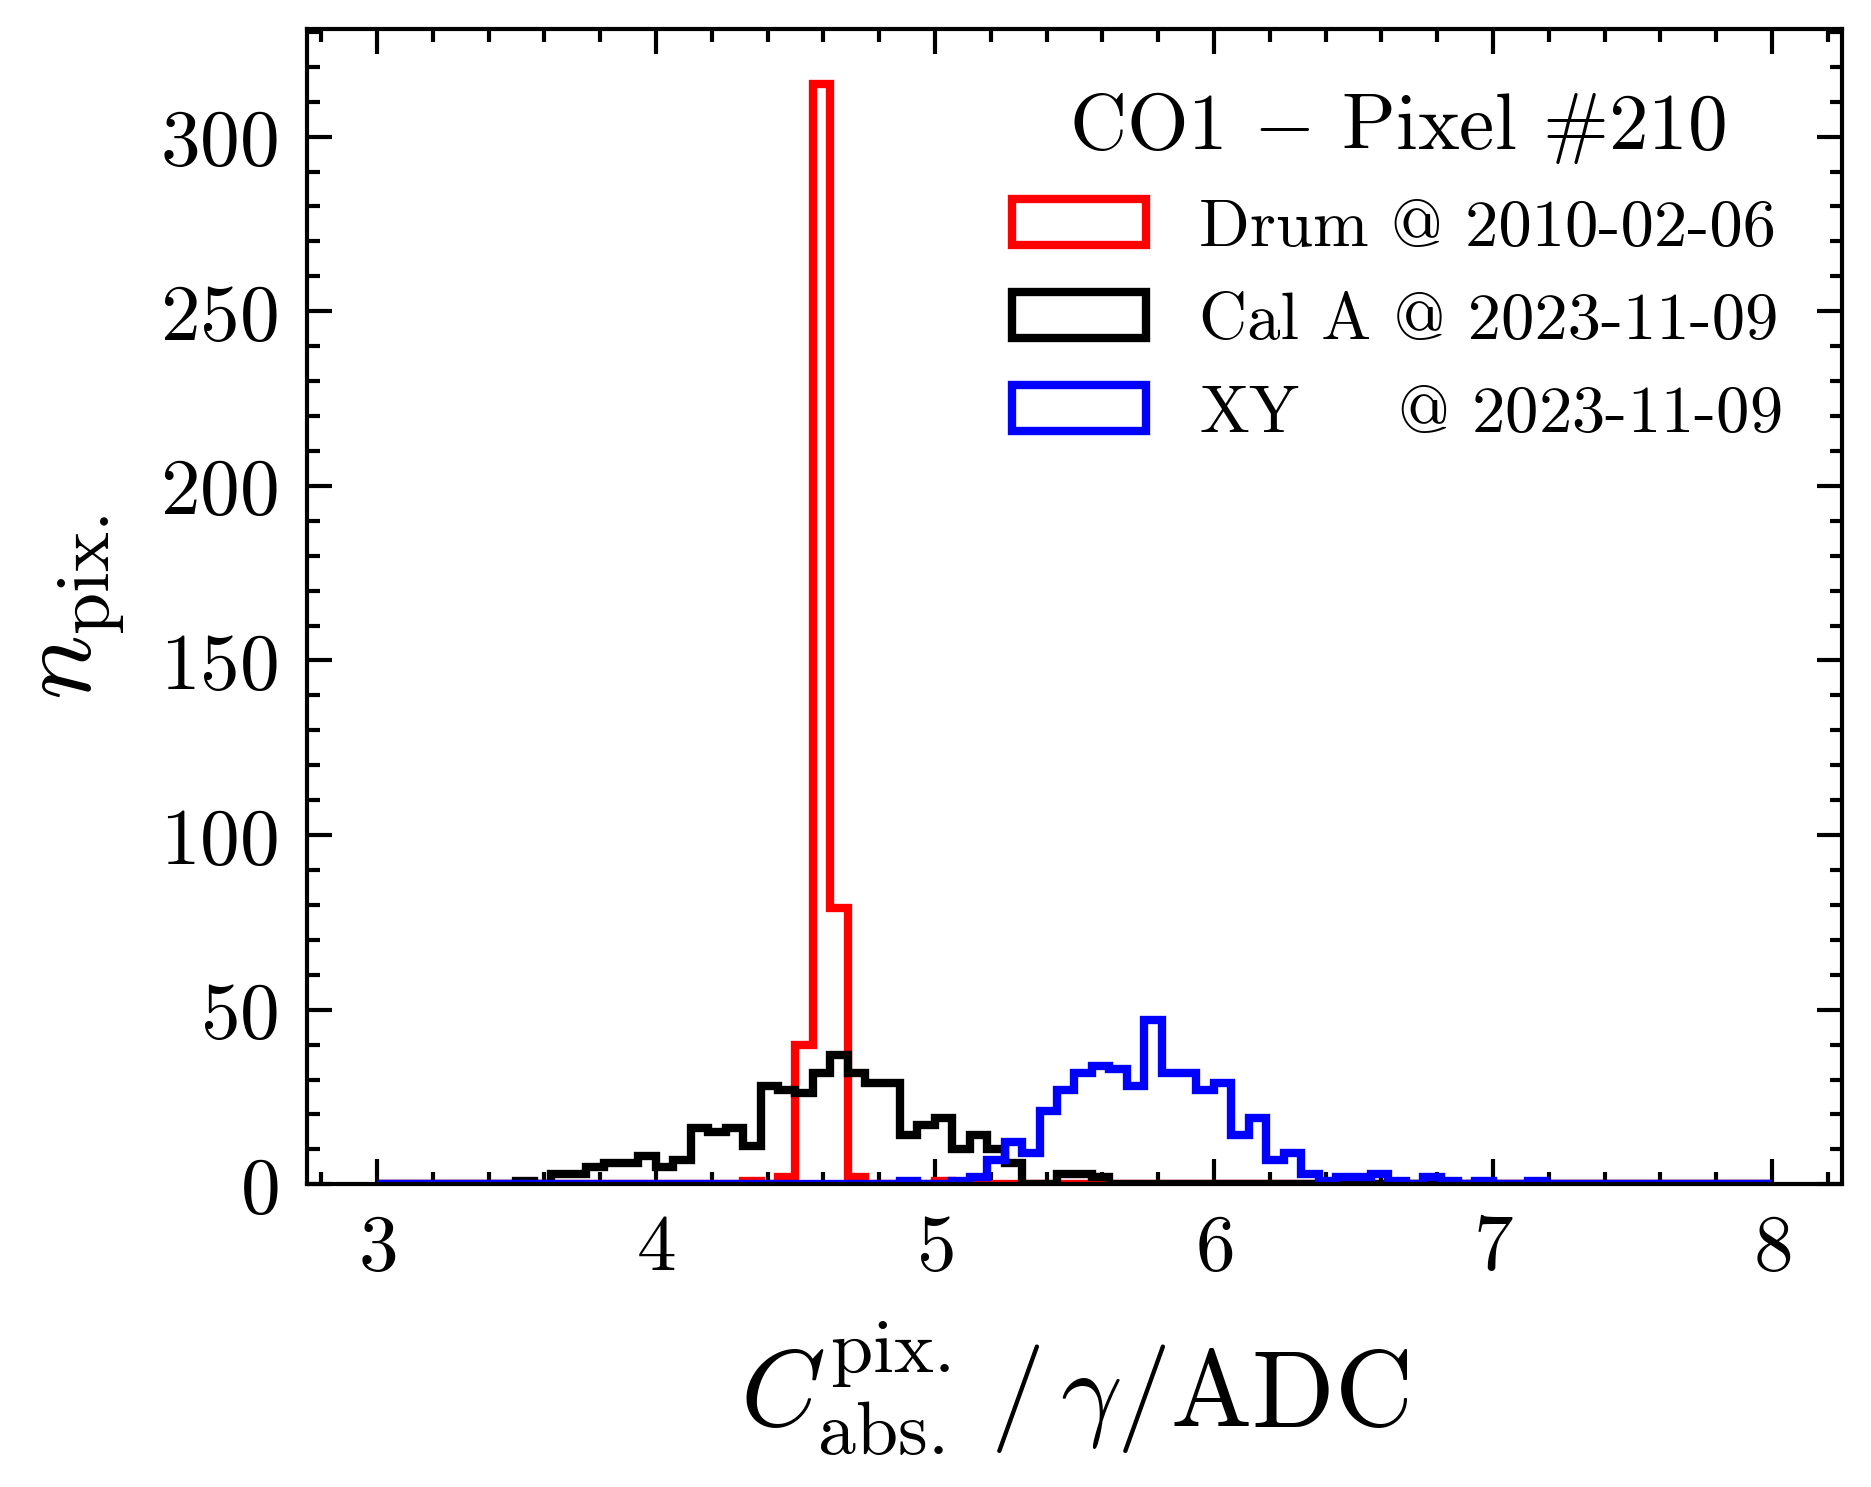

In [46]:
bins = {'bins': 80, 'range': (3, 8)}

# set_plt_style("double")

_ = plt.hist(calA_then, histtype='step', color='r', ls='-', label='Drum @ 2010-02-06', **bins, )
_ = plt.hist(calA_now, histtype='step', color='k', ls='-', label='Cal A @ 2023-11-09', **bins,)
_ = plt.hist(XY_now, histtype='step', color='b', ls='-', label='XY  $\,$  @ 2023-11-09', **bins, )

plt.ylabel("$n_\mathrm{pix.}$")
plt.legend(title="CO1 $-$ Pixel #210", fontsize=8)
plt.xlabel("$C^\mathrm{pix.}_\mathrm{abs.}\,/\,\gamma/\mathrm{ADC}$")
plot.save(plt.gcf(), "calib_drift")


In [36]:
CO1.year_month_day

'2023-11-09'